<a href="https://colab.research.google.com/github/abdel7amed129/Car-Price-Prediction-ML-Pipeline/blob/main/Notebooks/Car_Price_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Task 1 : Exploratory Data Analysis (EDA)


In [ ]:
import plotly.express as px
import plotly.graph_objects as go
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import plotly as plty
import seaborn as sns

car_prices = pd.read_csv("/content/car_price.csv")
df = pd.DataFrame(car_prices)

- How many rows and columns does the dataset have?


In [ ]:
print(car_prices.shape)

(72435, 10)


- Which features are numerical? Which are categorical?



1-loop in each column and detect type then insert them in a list


In [ ]:
categorical_features = []
numerical_features = []

for col in car_prices.columns:
  if car_prices[col].dtype == "int64" or car_prices[col].dtype == "float64" :
    numerical_features.append(car_prices[col].name)
  else :
    categorical_features.append(car_prices[col].name)
print(f'Numerical features are : {", ".join(numerical_features)}')
print(f'Categorical features are : {",".join(categorical_features)}')

Numerical features are : year, price, mileage, tax, mpg, engineSize
Categorical features are : model,transmission,fuelType,Make


- Are there any missing values? How many, and in which columns?




In [ ]:
na_columns = []
for col in df.columns:
  if df[col].hasnans == True:
    na_columns.append(df[col].name)
print(f'There is missing values in: {",".join(na_columns)}')

for col in na_columns:
  print(f"Sum of missing values in {col} : is {df[col].isna().sum()}")

There is missing values in: model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize,Make
Sum of missing values in model : is 3621
Sum of missing values in year : is 3622
Sum of missing values in price : is 3621
Sum of missing values in transmission : is 3623
Sum of missing values in mileage : is 3622
Sum of missing values in fuelType : is 3622
Sum of missing values in tax : is 3621
Sum of missing values in mpg : is 3621
Sum of missing values in engineSize : is 3622
Sum of missing values in Make : is 3621


* Optimized solution

In [ ]:
missing_values = df.isna().sum()
print(missing_values[missing_values > 0])

model           3621
year            3622
price           3621
transmission    3623
mileage         3622
fuelType        3622
tax             3621
mpg             3621
engineSize      3622
Make            3621
dtype: int64


- What does the distribution of car prices look like?


(array([3.5659e+04, 2.7397e+04, 4.4300e+03, 1.0210e+03, 2.3100e+02,
        4.6000e+01, 1.2000e+01, 5.0000e+00, 8.0000e+00, 5.0000e+00]),
 array([   495. ,  14945.5,  29396. ,  43846.5,  58297. ,  72747.5,
         87198. , 101648.5, 116099. , 130549.5, 145000. ]),
 <BarContainer object of 10 artists>)

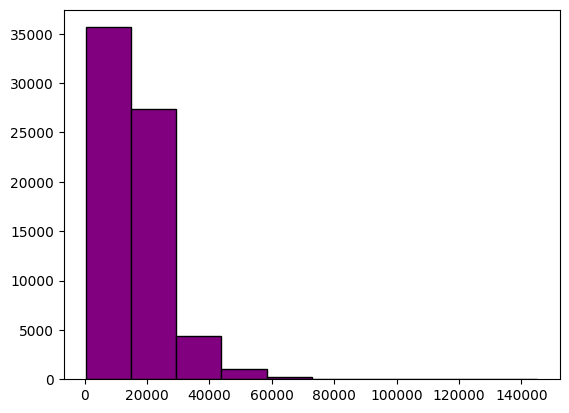

In [ ]:
plt.hist(df['price'],color = 'purple', edgecolor = 'black')


- Which features seem most related to price?




In [ ]:
# هتحسب الـ Correlation Matrix للأعمدة الرقمية فقط
# افترضنا إن df هو الـ DataFrame الأصلي بتاعك بعد الـ Preprocessing
numerical_cols = ['year', 'price', 'mileage', 'tax', 'mpg', 'engineSize']
corr_matrix = df[numerical_cols].corr()

# رسم الـ Heatmap
fig2 = px.imshow(
    corr_matrix,
    text_auto='.2f', # عشان يظهر الأرقام جوه المربعات برقمين عشريين
    aspect="auto",
    color_continuous_scale='RdBu_r', # تدريج ألوان ممتاز للـ Correlation (أحمر للأزرق)
    title='Features Correlation Heatmap',
    template='plotly_white'
)

fig2.update_layout(title_x=0.5)
fig2.show()

# Task 2 : Data Preprocessing


- Handle missing values by Fill missing values in numerical columns with their respective medians and Fill missing values in categorical columns with their respective modes

In [ ]:
for col in numerical_features:
    df[col].fillna(df[col].median(), inplace=True)
# Fill missing values in categorical columns with their respective modes
for col in categorical_features:
    # .mode() can sometimes return multiple values if there is a tie,
    # so we use [0] to ensure we only grab the very first one.
    df[col].fillna(df[col].mode()[0], inplace=True)

df.shape

/tmp/ipykernel_874/1713672385.py:2: FutureWarning:

A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.



/tmp/ipykernel_874/1713672385.py:2: FutureWarning:

A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or d

(72435, 10)

In [ ]:
for col in categorical_features:
  print(f'Valeus of {col} are {df[col].unique()}')

Valeus of model are [' A1' ' A6' ' A4' ' A3' ' Q3' ' Q5' ' A5' ' Fiesta' ' S4' ' Q2' ' A7'
 ' TT' ' Q7' ' RS6' ' RS3' ' A8' ' Q8' ' RS4' ' RS5' ' R8' ' SQ5' ' S8'
 ' SQ7' ' S3' ' S5' ' A2' ' RS7' ' 5 Series' ' 6 Series' ' 7 Series'
 ' 2 Series' ' 4 Series' ' 1 Series' ' X3' ' 3 Series' ' X5' ' X4' ' i3'
 ' X1' ' M4' ' X2' ' X6' ' 8 Series' ' Z4' ' X7' ' M5' ' i8' ' M2' ' M3'
 ' M6' ' Z3' ' Focus' ' Puma' ' Kuga' ' EcoSport' ' C-MAX' ' Mondeo'
 ' Ka+' ' Tourneo Custom' ' S-MAX' ' B-MAX' ' Edge' ' Tourneo Connect'
 ' Grand C-MAX' ' KA' ' Galaxy' ' Mustang' ' Grand Tourneo Connect'
 ' Fusion' ' Ranger' ' Streetka' ' Escort' ' T-Roc' ' Golf' ' Passat'
 ' T-Cross' ' Polo' ' Tiguan' ' Sharan' ' Up' ' Scirocco' ' Beetle'
 ' Caddy Maxi Life' ' Caravelle' ' Touareg' ' Arteon' ' Touran' ' Golf SV'
 ' Amarok' ' Tiguan Allspace' ' Shuttle' ' Jetta' ' CC' ' California'
 ' Caddy Life' ' Caddy' ' Caddy Maxi' ' Eos' ' Fox' ' GT86' ' Corolla'
 ' RAV4' ' Yaris' ' Auris' ' Aygo' ' C-HR' ' Prius' ' Avensi

- We Will use One-Hot Encoding because the data is Nominal

Due to the high cardinality in model column we use Grouping Rare Categories to handle them

We Will use the Cumulative Percentage to replace the bottom 10% of data with other then group them to apply one-hot-encoding

In [ ]:
model_percentage = df['model'].value_counts(normalize=True) # tell what each model percentage of total data
cum_percentage = model_percentage.cumsum() # running total the percentage
top_models = cum_percentage[cum_percentage <= 0.91].index # Catch the top 90% models
top_models_check = df['model'].isin(top_models)    # return all top cars with true and the other with false
other = ~top_models_check # ~ turn all other car to true values
df.loc[other , 'model'] = 'Other' # look inside the df the other values and turn it to Other



- Apply One-Hot Encoding

In [ ]:
df = pd.get_dummies(df,columns = categorical_features , drop_first = True)

- Scaling Numerical Features With Standard Scaler

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

df[numerical_features] = scaler.fit_transform(df[numerical_features])

- Detect and handle outliers — use boxplots or the IQR method.


In [ ]:
Q1 = df[numerical_features].quantile(0.25)
Q3 = df[numerical_features].quantile(0.75)
IQR = Q3 - Q1
upper_bound = Q3 + 1.5 * IQR
lower_bound = Q1 - 1.5 * IQR
# This creates a grid of True (it is an outlier) and False (it is normal)
outlier_flags = (df[numerical_features] > upper_bound) | (df[numerical_features] < lower_bound)
for col in numerical_features :
  df[col] = df[col].clip(lower=lower_bound[col], upper=upper_bound[col])
df

,year,price,mileage,tax,mpg,engineSize,model_ 2 Series,model_ 3 Series,model_ 4 Series,model_ 5 Series,...,fuelType_Electric,fuelType_Hybrid,fuelType_Other,fuelType_Petrol,Make_Ford,Make_Hyundai,Make_audi,Make_skoda,Make_toyota,Make_vw
0,-0.036052,-0.438260,-0.343586,0.504579,-0.024954,-0.426627,False,False,False,False,...,False,False,False,True,False,False,True,False,False,False
1,-0.524724,0.002258,0.638405,-0.371803,0.504773,0.669144,False,False,False,False,...,False,False,False,False,False,False,True,False,False,False
2,-0.524724,-0.603454,0.338213,-0.371803,-0.024954,-0.426627,False,False,False,False,...,False,False,False,True,False,False,True,False,False,False
3,-0.036052,0.035297,0.146594,0.424908,0.691382,0.669144,False,False,False,False,...,False,False,False,False,False,False,True,False,False,False
4,0.941290,0.090362,-1.002645,0.424908,-0.374092,-1.157141,False,False,False,False,...,False,False,False,True,False,False,True,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
72430,-0.524724,-0.858954,0.144387,-0.371803,1.359560,-0.061370,False,False,False,False,...,False,False,False,False,False,True,False,False,False,False
72431,-1.013395,-0.952564,-0.257900,-0.371803,0.595068,0.121258,False,False,False,False,...,False,False,False,False,False,True,False,False,False,False
72432,-0.036052,-1.062694,-0.435942,-0.371803,0.257969,-1.157141,False,False,False,False,...,False,False,False,True,True,False,False,False,False,False
72433,0.452619,-0.273726,0.019982,0.424908,-0.663034,-0.061370,False,False,False,False,...,False,False,False,True,False,True,False,False,False,False


# Task 3 : Create Two Target Variables


## A. Regression Target (Linear Regression)


### **Step 1 : Split data to Target and Features**

In [ ]:
Features_X = df.drop('price',axis=1)
Target_y = df['price']

### **Step 2 : The Train-Test Split (80-20)**

In [ ]:
from sklearn.model_selection import train_test_split
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(Features_X, Target_y, test_size=0.2, train_size=0.8, random_state=42)

### **Step 3: Train the Linear Regression Model**

In [ ]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train_reg,y_train_reg)

LinearRegression()

### **Step 4: The Final Exam (Evaluating the Model)**

In [ ]:
predicted_prices_reg = model.predict(X_test_reg)


#### **Evaluate Using MAE and MSE**

In [ ]:
# @title
from sklearn.metrics import mean_absolute_error, r2_score , mean_squared_error

mae = mean_absolute_error(y_test , predicted_prices)
print(mae)
mse = mean_squared_error(y_test , predicted_prices)
print(mse)

0.26379719420652126
0.1368813489456061


#### **Evaluate using R2 score**

In [ ]:
r2_score(y_test_reg , predicted_prices_reg)

0.8016320139814325

In [ ]:


# Find the index of 'price' in numerical_features to get its specific mean and scale from the scaler
price_col_index = numerical_features.index('price')
price_mean = scaler.mean_[price_col_index]
price_scale = scaler.scale_[price_col_index]

# Manually inverse transform y_test_reg and predicted_prices_reg using the specific mean and scale for 'price'
y_test_real = (y_test_reg.values.flatten() * price_scale) + price_mean
y_pred_real = (predicted_prices_reg.flatten() * price_scale) + price_mean

df_reg = pd.DataFrame({
    'Actual Price': y_test_real,
    'Predicted Price': y_pred_real
})

# 3. ارسم بـ Plotly عادي جداً والأرقام هتطلع حقيقية ومفهومة
fig1 = px.scatter(
    df_reg,
    x='Actual Price',
    y='Predicted Price',
    title='Predicted vs. Actual Car Prices (R² = 0.80)',
    labels={'Actual Price': 'Actual Price ($)', 'Predicted Price': 'Predicted Price ($)'},
    opacity=0.6,
    template='plotly_white'
)

# إضافة الخط المثالي بناءً على الأسعار الحقيقية
min_val = min(df_reg['Actual Price'].min(), df_reg['Predicted Price'].min())
max_val = max(df_reg['Actual Price'].max(), df_reg['Predicted Price'].max())

fig1.add_shape(
    type="line",
    x0=min_val, y0=min_val, x1=max_val, y1=max_val,
    line=dict(color="Red", width=2, dash="dash")
)

fig1.update_layout(title_x=0.5)
fig1.show()

## B. Classification Target (KNN)

### **Step 1 : Classify car prices to 3 categories**

- **We used quantiles to automatically divide the prices into
three exact thirds (33.3%, 66.6%, 100%). This ensures the categories are perfectly balanced. If we guessed thresholds manually, we might accidentally put 80% of the dataset into the 'Moderate' category. If that happened, the KNN model would become biased, lazily guessing 'Moderate' for every car without actually learning anything. By splitting the distribution into equal thirds, the model is forced to genuinely learn the features of all three categories**

In [ ]:
from sklearn.neighbors import KNeighborsClassifier

df['price_category'] , bins = pd.qcut(df['price'],q=3,labels=['Cheap','Moderate','Expensive'],retbins=True)
print(bins)

[-1.76036399 -0.52085678  0.13980992  1.96779397]


In [ ]:

price_col_index = numerical_features.index('price')
price_mean = scaler.mean_[price_col_index]
price_scale = scaler.scale_[price_col_index]
prices_real = (df['price'].values.flatten() * price_scale) + price_mean

# هنعمل DataFrame مؤقت للرسم
df_hist = pd.DataFrame({'real_price': prices_real})

# 2. حساب الـ Quantiles المظبوطة
q33 = df_hist['real_price'].quantile(0.333)
q66 = df_hist['real_price'].quantile(0.666)

# إضافة عمود الفئة لتلوين الهيستوجرام
def categorize(p):
    if p <= q33: return 'Cheap'
    elif p <= q66: return 'Moderate'
    else: return 'Expensive'

df_hist['Category'] = df_hist['real_price'].apply(categorize)

# 3. رسم الـ Histogram مع الألوان المخصصة
fig3 = px.histogram(
    df_hist,
    x='real_price',
    color='Category',
    title='Car Price Distribution by Category',
    labels={'real_price': 'Price ($)'},
    template='plotly_white',
    color_discrete_map={
        'Cheap': 'skyblue',
        'Moderate': 'green',
        'Expensive': 'red'
    },
    category_orders={'Category': ['Cheap', 'Moderate', 'Expensive']}
)

# 4. إضافة الخطوط الفاصلة الرأسية
fig3.add_vline(
    x=q33, line_width=2.5, line_dash="dash", line_color="Black",
    annotation_text=f"Limit ({int(q33)}$)", annotation_position="top left"
)
fig3.add_vline(
    x=q66, line_width=2.5, line_dash="dash", line_color="Black",
    annotation_text=f"Limit ({int(q66)}$)", annotation_position="top left"
)

fig3.update_layout(title_x=0.5, yaxis_title="Number of Cars", bargap=0.1)
fig3.show()

### **Step 2 : Define Target and Features**

In [ ]:
X = df.drop(['price_category','price'] , axis = 1)
y = df['price_category']

### **Step 3 : Train-Test Split**

In [ ]:
X_train, X_test, y_train , y_test = train_test_split(X , y , test_size= 0.2 , random_state=42)

### **Step 4: - Used Grid Search, kfold to find the best combination of parameters**

In [ ]:
param_grid = {
    'n_neighbors' : [3,5,7,9] ,
    'metric' : ['euclidean' , 'manhattan']
}

from sklearn.model_selection import GridSearchCV

grid_search = GridSearchCV(estimator=KNeighborsClassifier() , param_grid=param_grid , cv=5 , n_jobs = 1)
# Grid search has found the best model So we will train it
grid_search.fit(X_train , y_train )


GridSearchCV(cv=5, estimator=KNeighborsClassifier(), n_jobs=1,
             param_grid={'metric': ['euclidean', 'manhattan'],
                         'n_neighbors': [3, 5, 7, 9]})

### **Step 5: The Final Exam (Evaluating the Model)**

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix

Knn_predicitions = grid_search.predict(X_test)

report = classification_report(y_test , Knn_predicitions)
conf_matrix = confusion_matrix(y_test , Knn_predicitions)
print("Classification Report:\n",report)
print("\nConfusion Matrix:\n", conf_matrix)

Classification Report:
               precision    recall  f1-score   support

       Cheap       0.86      0.90      0.88      4876
   Expensive       0.88      0.90      0.89      4876
    Moderate       0.79      0.73      0.76      4735

    accuracy                           0.85     14487
   macro avg       0.84      0.84      0.84     14487
weighted avg       0.84      0.85      0.84     14487


Confusion Matrix:
 [[4409    8  459]
 [  33 4368  475]
 [ 681  581 3473]]


In [ ]:
# @title
from sklearn.metrics import confusion_matrix

# افترضنا إن عندك y_test_class (الحقيقي) و y_pred_class (توقع الـ KNN)
categories = ['Cheap', 'Moderate', 'Expensive']
cm = confusion_matrix(y_test, Knn_predicitions, labels=categories)

# رسم الـ Confusion Matrix
fig4 = px.imshow(
    cm,
    x=categories,
    y=categories,
    text_auto=True, # بيظهر الأرقام جوه المربعات تلقائياً
    color_continuous_scale='Blues', # تدريج أزرق مريح للعين
    title='KNN Confusion Matrix (Accuracy = 85%)',
    labels=dict(x="Predicted Category", y="Actual Category"),
    template='plotly_white'
)

# تظبيط شكل المحاور والعنوان
fig4.update_layout(
    title_x=0.5,
    xaxis_title="Predicted",
    yaxis_title="Actual"
)
fig4.show()